# PBV v5 — Causal Variant

This notebook converts `pbv_v5_final` into a causal execution benchmark.

Core design choices:
- keep the PBV bucket representation from `pbv_v3`
- keep **deep** order book imbalance from levels 2-5 only
- de-emphasize broad `d2` usage and center the model on cumulative state + `d1`
- replace the within-minute top-decile label with a **train-calibrated current-tick label**
- replace argmax-over-window with a **causal first-hit threshold policy**
- split minutes into **fit / validation / test** chronologically
- select the model on **validation AUC only**
- tune the execution threshold on **validation minutes only**
- retain the `v3` rule baseline as an interpretable comparator


In [12]:
# ============================================================
# CELL 1: Imports & Config
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

STOCK                 = "INTC"
STOCKS_ALL            = ["AMZN", "GOOG", "INTC", "MSFT"]
SIDE                  = "BUY"
WARMUP_TICKS          = 30
DEADLINE_S            = 45.0
TRAIN_FRAC            = 0.70   # earliest 70% of eligible minutes reserved for fit+validation
VAL_FRAC_WITHIN_TRAIN = 0.20   # last 20% of the train block used for validation only
TOP_Q                 = 0.90   # fit-set quantile for a strong current-tick label
EPS                   = 1e-6
RANDOM_STATE          = 42
PROB_GRID             = np.linspace(0.50, 0.90, 17)

EXEC_PRICE_COL = "AskPrice_1" if SIDE == "BUY" else "BidPrice_1"
OBI_LEVELS     = range(2, 6)

# Final candidate: d1 + cumulative state + deep OBI
FEAT_FINAL = [
    "v_ask_near_d1", "v_ask_far_d1",
    "v_mid_cum", "v_ask_near_cum", "v_bid_near_cum",
    "Spread", "elapsed",
    "v_obi", "v_obi_cum",
]

# Baselines for ablation / comparison
FEAT_BASE_LEAN = [
    "v_ask_near_d1", "v_ask_far_d1",
    "v_mid_cum", "v_ask_near_cum", "v_bid_near_cum",
    "Spread", "elapsed",
]
FEAT_WITH_OBI = FEAT_BASE_LEAN + ["v_obi", "v_obi_cum"]
FEAT_WITH_D2  = FEAT_WITH_OBI + ["v_ask_near_d2", "v_bid_near_d2"]

print(f"Side: {SIDE} | Exec col: {EXEC_PRICE_COL}")
print(f"Warmup: {WARMUP_TICKS} ticks | Deadline: {DEADLINE_S}s")
print(f"Outer train frac: {TRAIN_FRAC:.2f} | Validation frac within train: {VAL_FRAC_WITHIN_TRAIN:.2f}")
print(f"Target: top {100*(1-TOP_Q):.0f}% of fit eligible ticks by current realized improvement")
print(f"Threshold grid: {PROB_GRID[0]:.2f} -> {PROB_GRID[-1]:.2f} ({len(PROB_GRID)} values)")
print(f"FEAT_BASE_LEAN ({len(FEAT_BASE_LEAN)}): {FEAT_BASE_LEAN}")
print(f"FEAT_WITH_OBI ({len(FEAT_WITH_OBI)}): {FEAT_WITH_OBI}")
print(f"FEAT_WITH_D2 ({len(FEAT_WITH_D2)}): {FEAT_WITH_D2}")
print(f"FEAT_FINAL ({len(FEAT_FINAL)}): {FEAT_FINAL}")


Side: BUY | Exec col: AskPrice_1
Warmup: 30 ticks | Deadline: 45.0s
Outer train frac: 0.70 | Validation frac within train: 0.20
Target: top 10% of fit eligible ticks by current realized improvement
Threshold grid: 0.50 -> 0.90 (17 values)
FEAT_BASE_LEAN (7): ['v_ask_near_d1', 'v_ask_far_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed']
FEAT_WITH_OBI (9): ['v_ask_near_d1', 'v_ask_far_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed', 'v_obi', 'v_obi_cum']
FEAT_WITH_D2 (11): ['v_ask_near_d1', 'v_ask_far_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed', 'v_obi', 'v_obi_cum', 'v_ask_near_d2', 'v_bid_near_d2']
FEAT_FINAL (9): ['v_ask_near_d1', 'v_ask_far_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed', 'v_obi', 'v_obi_cum']


In [13]:
# ============================================================
# CELL 2: Data Load + PBV Buckets + Deep OBI + Causal Improvement
# ============================================================
def load_and_compute(stock):
    d = pd.read_csv(f"training_datasets/{stock}_5levels_train.csv")
    d["Time_dt"] = pd.to_datetime(d["Time"], format="%H:%M:%S.%f")
    d = d.sort_values("Time_dt").reset_index(drop=True)

    d["Minute"]  = d["Time_dt"].dt.floor("min")
    d["elapsed"] = (d["Time_dt"] - d["Minute"]).dt.total_seconds()
    d["tick_in_minute"] = d.groupby("Minute").cumcount()
    d["eligible"] = (d["tick_in_minute"] >= WARMUP_TICKS) & (d["elapsed"] <= DEADLINE_S)

    mid = d["MidPrice"]
    b1, a1 = d["BidSize_1"], d["AskSize_1"]

    # Core PBV buckets
    d["v_mid"]      = (b1 - a1) / (b1 + a1 + EPS)
    d["v_ask_near"] = d["AskSize_1"] / (d["AskPrice_1"] - mid).clip(lower=EPS)
    d["v_ask_far"]  = sum(d[f"AskSize_{i}"] / (d[f"AskPrice_{i}"] - mid).clip(lower=EPS) for i in range(2, 6))
    d["v_bid_near"] = d["BidSize_1"] / (mid - d["BidPrice_1"]).clip(lower=EPS)
    d["v_bid_far"]  = sum(d[f"BidSize_{i}"] / (mid - d[f"BidPrice_{i}"]).clip(lower=EPS) for i in range(2, 6))

    # Deep imbalance: levels 2-5 only
    bid_pressure = sum(d[f"BidSize_{i}"] / (mid - d[f"BidPrice_{i}"]).clip(lower=EPS) for i in OBI_LEVELS)
    ask_pressure = sum(d[f"AskSize_{i}"] / (d[f"AskPrice_{i}"] - mid).clip(lower=EPS) for i in OBI_LEVELS)
    d["v_obi"] = (bid_pressure - ask_pressure) / (bid_pressure + ask_pressure + EPS)

    bucket_cols = ["v_mid", "v_ask_near", "v_ask_far", "v_bid_near", "v_bid_far", "v_obi"]
    grp = d.groupby("Minute")
    for col in bucket_cols:
        d[f"{col}_cum"] = grp[col].cumsum()
        d[f"{col}_d1"]  = grp[f"{col}_cum"].diff()
        d[f"{col}_d2"]  = grp[f"{col}_d1"].diff()

    # Strictly causal benchmark for labels / tuning: minute-open price
    causal_ref = grp[EXEC_PRICE_COL].transform("first")
    d["causal_ref"] = causal_ref
    d["causal_improvement"] = (causal_ref - d[EXEC_PRICE_COL]) if SIDE == "BUY" else (d[EXEC_PRICE_COL] - causal_ref)

    # Evaluation columns match the causal benchmark in this notebook
    d["eval_ref"] = d["causal_ref"]
    d["eval_improvement"] = d["causal_improvement"]
    d["stock"] = stock
    return d


train_raw = load_and_compute(STOCK)
print(f"Shape: {train_raw.shape} | Minutes: {train_raw['Minute'].nunique()}")
print(f"Eligible ticks: {train_raw['eligible'].sum()} / {len(train_raw)} ({100*train_raw['eligible'].mean():.1f}%)")
print(f"Causal realized improvement > 0 among eligible: {100*(train_raw.loc[train_raw['eligible'], 'causal_improvement'] > 0).mean():.2f}%")
print(f"corr(v_obi, v_mid) = {train_raw[['v_obi','v_mid']].corr().iloc[0,1]:.3f}")
print(train_raw[["v_obi", "v_obi_cum", "causal_improvement"]].describe().round(4))


Shape: (430718, 67) | Minutes: 270
Eligible ticks: 317655 / 430718 (73.8%)
Causal realized improvement > 0 among eligible: 37.59%
corr(v_obi, v_mid) = 0.153
             v_obi    v_obi_cum  causal_improvement
count  430718.0000  430718.0000         430718.0000
mean        0.0527      28.7953              0.0041
std         0.1585     371.9279              0.0217
min        -0.8194   -2376.7366             -0.0900
25%        -0.0288      -8.5906             -0.0100
50%         0.0441      20.9502              0.0000
75%         0.1246      86.5604              0.0100
max         0.9826    2572.6073              0.1400


In [14]:
# ============================================================
# CELL 3: Chronological Fit / Validation / Test Split + Causal Label
# ============================================================
def split_minutes(df):
    minutes_sorted = sorted(df.loc[df["eligible"], "Minute"].unique())
    n_train_block = int(len(minutes_sorted) * TRAIN_FRAC)
    train_block = minutes_sorted[:n_train_block]
    test_mins = set(minutes_sorted[n_train_block:])

    n_fit = int(len(train_block) * (1 - VAL_FRAC_WITHIN_TRAIN))
    fit_mins = set(train_block[:n_fit])
    val_mins = set(train_block[n_fit:])
    return fit_mins, val_mins, test_mins


def build_dataset(df, feature_cols, fit_mins, val_mins, test_mins):
    df_elig = df[df["eligible"]].copy()
    df_fit = df_elig[df_elig["Minute"].isin(fit_mins)].dropna(subset=feature_cols).copy()
    df_val = df_elig[df_elig["Minute"].isin(val_mins)].dropna(subset=feature_cols).copy()
    df_test = df_elig[df_elig["Minute"].isin(test_mins)].dropna(subset=feature_cols).copy()
    return df_elig, df_fit, df_val, df_test


def apply_causal_label(df_fit, df_val, df_test, improvement_cutoff, improvement_col="causal_improvement"):
    df_fit = df_fit.copy()
    df_val = df_val.copy()
    df_test = df_test.copy()
    df_fit["label_strong_now"] = (df_fit[improvement_col] >= improvement_cutoff).astype(int)
    df_val["label_strong_now"] = (df_val[improvement_col] >= improvement_cutoff).astype(int)
    df_test["label_strong_now"] = (df_test[improvement_col] >= improvement_cutoff).astype(int)
    return df_fit, df_val, df_test


fit_mins, val_mins, test_mins = split_minutes(train_raw)
fit_pool = train_raw[train_raw["eligible"] & train_raw["Minute"].isin(fit_mins)].copy()
IMPROVEMENT_CUTOFF = fit_pool["causal_improvement"].quantile(TOP_Q)

_, diag_fit, diag_val, diag_test = build_dataset(train_raw, FEAT_WITH_D2, fit_mins, val_mins, test_mins)
diag_fit, diag_val, diag_test = apply_causal_label(diag_fit, diag_val, diag_test, IMPROVEMENT_CUTOFF)

print(f"Fit minutes: {len(fit_mins)} | Validation minutes: {len(val_mins)} | Test minutes: {len(test_mins)}")
print(f"Fit improvement cutoff @ q={TOP_Q:.2f}: {IMPROVEMENT_CUTOFF:0.5f}")
print(f"Fit rows  (diag set): {len(diag_fit)} | label rate={100*diag_fit['label_strong_now'].mean():.2f}%")
print(f"Val rows  (diag set): {len(diag_val)} | label rate={100*diag_val['label_strong_now'].mean():.2f}%")
print(f"Test rows (diag set): {len(diag_test)} | label rate={100*diag_test['label_strong_now'].mean():.2f}%")


Fit minutes: 151 | Validation minutes: 38 | Test minutes: 81
Fit improvement cutoff @ q=0.90: 0.03000
Fit rows  (diag set): 202278 | label rate=11.03%
Val rows  (diag set): 45621 | label rate=4.93%
Test rows (diag set): 69756 | label rate=1.34%


In [15]:
# ============================================================
# CELL 4: Fit Models — Select by Validation AUC Only
# ============================================================
def fit_model(feat_cols, df_fit, df_val, df_test):
    sc = StandardScaler()
    Xfit = sc.fit_transform(df_fit[feat_cols].values)
    Xval = sc.transform(df_val[feat_cols].values)
    Xtest = sc.transform(df_test[feat_cols].values)
    yfit = df_fit["label_strong_now"].values
    yval = df_val["label_strong_now"].values
    ytest = df_test["label_strong_now"].values

    model = LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
    model.fit(Xfit, yfit)
    fit_auc = roc_auc_score(yfit, model.predict_proba(Xfit)[:, 1])
    val_auc = roc_auc_score(yval, model.predict_proba(Xval)[:, 1])
    test_auc = roc_auc_score(ytest, model.predict_proba(Xtest)[:, 1])
    return model, sc, fit_auc, val_auc, test_auc


model_specs = {
    "lean_pbv": FEAT_BASE_LEAN,
    "lean_pbv_plus_obi": FEAT_WITH_OBI,
    "lean_pbv_plus_obi_plus_d2": FEAT_WITH_D2,
}

fit_results = {}
for name, feats in model_specs.items():
    _, df_fit_raw, df_val_raw, df_test_raw = build_dataset(train_raw, feats, fit_mins, val_mins, test_mins)
    df_fit, df_val, df_test = apply_causal_label(df_fit_raw, df_val_raw, df_test_raw, IMPROVEMENT_CUTOFF)
    model, sc, fit_auc, val_auc, test_auc = fit_model(feats, df_fit, df_val, df_test)
    fit_results[name] = {
        "model": model,
        "scaler": sc,
        "fit_auc": fit_auc,
        "val_auc": val_auc,
        "test_auc": test_auc,
        "df_fit": df_fit,
        "df_val": df_val,
        "df_test": df_test,
    }

print(f"{'Model':<28} {'Features':>8}  {'Fit AUC':>8}  {'Val AUC':>8}  {'Test AUC':>9}")
print('-' * 76)
for name, feats in model_specs.items():
    info = fit_results[name]
    print(f"{name:<28} {len(feats):>8}  {info['fit_auc']:>8.4f}  {info['val_auc']:>8.4f}  {info['test_auc']:>9.4f}")

selected_name = max(model_specs, key=lambda k: fit_results[k]["val_auc"])
print(f"\nSelected model by validation AUC: {selected_name}")

coef_df = pd.DataFrame({
    "feature": model_specs[selected_name],
    "coef": fit_results[selected_name]["model"].coef_[0],
}).sort_values("coef")
print("\nSelected-model coefficients:")
print(coef_df.to_string(index=False, float_format=lambda x: f"{x:0.4f}"))


Model                        Features   Fit AUC   Val AUC   Test AUC
----------------------------------------------------------------------------
lean_pbv                            7    0.9450    0.8533     0.9817
lean_pbv_plus_obi                   9    0.9544    0.8620     0.9878
lean_pbv_plus_obi_plus_d2          11    0.9544    0.8620     0.9878

Selected model by validation AUC: lean_pbv_plus_obi

Selected-model coefficients:
       feature    coef
  v_ask_far_d1 -2.4782
     v_mid_cum -0.7732
     v_obi_cum -0.6997
 v_ask_near_d1 -0.5770
        Spread -0.4203
       elapsed -0.1734
v_bid_near_cum -0.0964
         v_obi  0.1026
v_ask_near_cum  1.7916


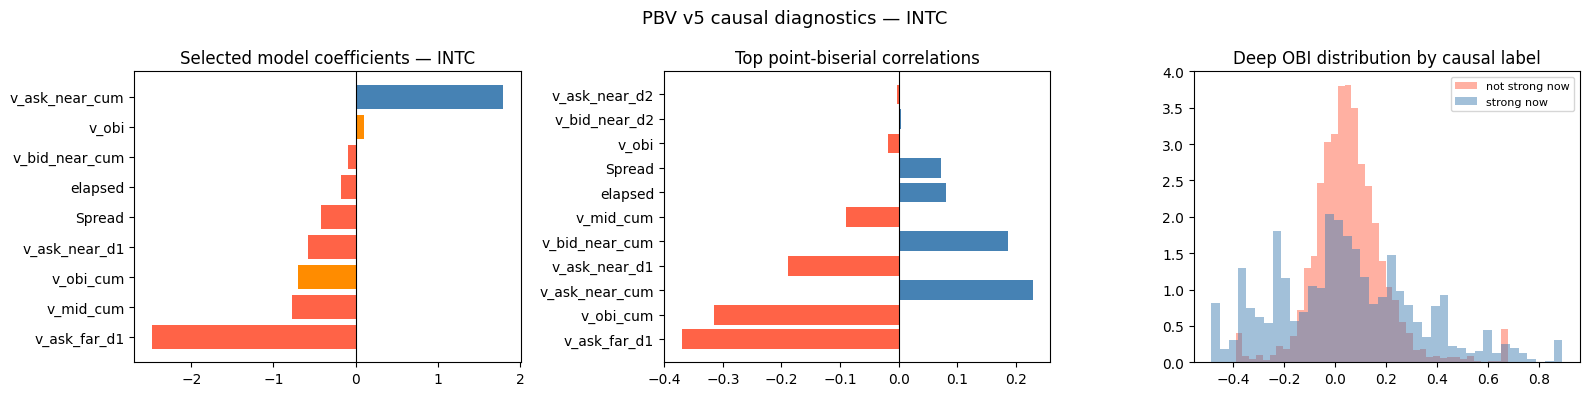

Top feature correlations with causal label:
v_ask_far_d1     -0.3704
v_obi_cum        -0.3145
v_ask_near_cum    0.2287
v_ask_near_d1    -0.1887
v_bid_near_cum    0.1868
v_mid_cum        -0.0898
elapsed           0.0803
Spread            0.0718
v_obi            -0.0180
v_bid_near_d2     0.0038
v_ask_near_d2    -0.0028


In [16]:
# ============================================================
# CELL 5: Single-Stock Diagnostics
# ============================================================
diag_df = train_raw[train_raw['eligible']].dropna(subset=model_specs[selected_name]).copy()
diag_df['label_strong_now'] = (diag_df['causal_improvement'] >= IMPROVEMENT_CUTOFF).astype(int)

feat_corr = diag_df[sorted(set(FEAT_WITH_D2)) + ['label_strong_now']].corr()['label_strong_now'].drop('label_strong_now')
feat_corr = feat_corr.sort_values(key=np.abs, ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

coef_colors = ["darkorange" if "obi" in f else ("steelblue" if c > 0 else "tomato") for f, c in zip(coef_df['feature'], coef_df['coef'])]
axes[0].barh(coef_df['feature'], coef_df['coef'], color=coef_colors, edgecolor='none')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title(f"Selected model coefficients — {STOCK}")

axes[1].barh(feat_corr.index[:12], feat_corr.values[:12], color=["steelblue" if v > 0 else "tomato" for v in feat_corr.values[:12]], edgecolor='none')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title("Top point-biserial correlations")

plot_df = diag_df[['v_mid', 'v_obi', 'label_strong_now']].copy()
for label, color, name in [(0, 'tomato', 'not strong now'), (1, 'steelblue', 'strong now')]:
    vals = plot_df.loc[plot_df['label_strong_now'] == label, 'v_obi']
    vals = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
    axes[2].hist(vals, bins=40, alpha=0.5, density=True, color=color, label=name, edgecolor='none')
axes[2].set_title("Deep OBI distribution by causal label")
axes[2].legend(fontsize=8)

plt.suptitle(f"PBV v5 causal diagnostics — {STOCK}", fontsize=13)
plt.tight_layout()
plt.show()

print("Top feature correlations with causal label:")
print(feat_corr.head(15).round(4).to_string())


In [17]:
# ============================================================
# CELL 6: Causal Simulation Functions
# ============================================================
def simulate_threshold(model, scaler, feat_cols, df_features, df_raw, prob_threshold, benchmark_col, improvement_col):
    df_s = df_features.copy()
    df_s['prob'] = model.predict_proba(scaler.transform(df_s[feat_cols].values))[:, 1]

    rows = []
    for minute, grp in df_s.groupby('Minute'):
        window = grp.sort_values('elapsed')
        benchmark_price = df_raw.loc[df_raw['Minute'] == minute, benchmark_col].iloc[0]

        fired = window[window['prob'] >= prob_threshold]
        if not fired.empty:
            exec_row = fired.iloc[0]
            fired_flag = True
        else:
            exec_row = window.iloc[-1]
            fired_flag = False

        oracle_window = df_raw[(df_raw['Minute'] == minute) & (df_raw['eligible'])]
        oracle_row = oracle_window.loc[oracle_window[improvement_col].idxmax()] if not oracle_window.empty else exec_row

        rows.append({
            'Minute': minute,
            'benchmark_price': benchmark_price,
            'pbv_price': exec_row[EXEC_PRICE_COL],
            'exec_s': exec_row['elapsed'],
            'score': exec_row['prob'],
            'fired': fired_flag,
            'improvement': exec_row[improvement_col],
            'oracle_improvement': oracle_row[improvement_col],
            'oracle_gap': oracle_row[improvement_col] - exec_row[improvement_col],
        })
    return pd.DataFrame(rows)


def tune_threshold(model, scaler, feat_cols, df_val_features, df_raw, benchmark_col, improvement_col, prob_grid=PROB_GRID):
    rows = []
    for thr in prob_grid:
        res = simulate_threshold(model, scaler, feat_cols, df_val_features, df_raw, thr, benchmark_col, improvement_col)
        rows.append({
            'threshold': thr,
            'mean_improvement': res['improvement'].mean(),
            'beat_pct': 100 * (res['improvement'] > 0).mean(),
            'fire_pct': 100 * res['fired'].mean(),
            'exec_s': res['exec_s'].mean(),
            'oracle_gap': res['oracle_gap'].mean(),
        })
    tune_df = pd.DataFrame(rows)
    best_idx = tune_df.sort_values(['mean_improvement', 'beat_pct', 'exec_s'], ascending=[False, False, True]).index[0]
    return tune_df.loc[best_idx, 'threshold'], tune_df


def simulate_v3_baseline(df_raw, eval_minutes, benchmark_col, improvement_col):
    rows = []
    df_v3 = df_raw[df_raw['Minute'].isin(eval_minutes)].copy()
    for minute, grp in df_v3.groupby('Minute'):
        grp = grp.sort_values('elapsed')
        benchmark_price = grp[benchmark_col].iloc[0]
        signal = (
            (grp['tick_in_minute'] >= WARMUP_TICKS) &
            (grp['v_ask_near_d2'] < 0) &
            (grp['v_mid_cum'] > 0) &
            (grp['elapsed'] <= DEADLINE_S)
        ).fillna(False)
        fired = grp[signal]
        if not fired.empty:
            exec_row = fired.iloc[0]
            fired_flag = True
        else:
            eligible = grp[grp['eligible']]
            exec_row = eligible.iloc[-1] if not eligible.empty else grp.iloc[-1]
            fired_flag = False

        eligible_for_oracle = grp[grp['eligible']]
        oracle_row = eligible_for_oracle.loc[eligible_for_oracle[improvement_col].idxmax()] if not eligible_for_oracle.empty else exec_row
        rows.append({
            'Minute': minute,
            'benchmark_price': benchmark_price,
            'pbv_price': exec_row[EXEC_PRICE_COL],
            'exec_s': exec_row['elapsed'],
            'score': np.nan,
            'fired': fired_flag,
            'improvement': exec_row[improvement_col],
            'oracle_improvement': oracle_row[improvement_col],
            'oracle_gap': oracle_row[improvement_col] - exec_row[improvement_col],
        })
    return pd.DataFrame(rows)


def summarize_results(label, res_df, val_auc=np.nan, test_auc=np.nan, prob_threshold=np.nan):
    return {
        'Model': label,
        'Val AUC': val_auc,
        'Test AUC': test_auc,
        'Threshold': prob_threshold,
        'Mean $': res_df['improvement'].mean(),
        'Median $': res_df['improvement'].median(),
        'Beat %': 100 * (res_df['improvement'] > 0).mean(),
        'Fire %': 100 * res_df['fired'].mean(),
        'Exec s': res_df['exec_s'].mean(),
        'Oracle $': res_df['oracle_improvement'].mean(),
        'Oracle gap $': res_df['oracle_gap'].mean(),
    }


                    Model  Val AUC  Test AUC  Threshold  Mean $  Median $   Beat %   Fire %   Exec s  Oracle $  Oracle gap $
                 lean_pbv  0.85332   0.98175    0.60000 0.00025   0.00000 25.92593  6.17284 43.51702   0.00469       0.00444
        lean_pbv_plus_obi  0.86200   0.98777    0.52500 0.00037   0.00000 27.16049  6.17284 43.59763   0.00469       0.00432
lean_pbv_plus_obi_plus_d2  0.86199   0.98783    0.60000 0.00049   0.00000 28.39506  4.93827 43.90601   0.00469       0.00420
         v3_rule_baseline      NaN       NaN        NaN 0.00148   0.00000 17.28395 70.37037 18.77914   0.00469       0.00321


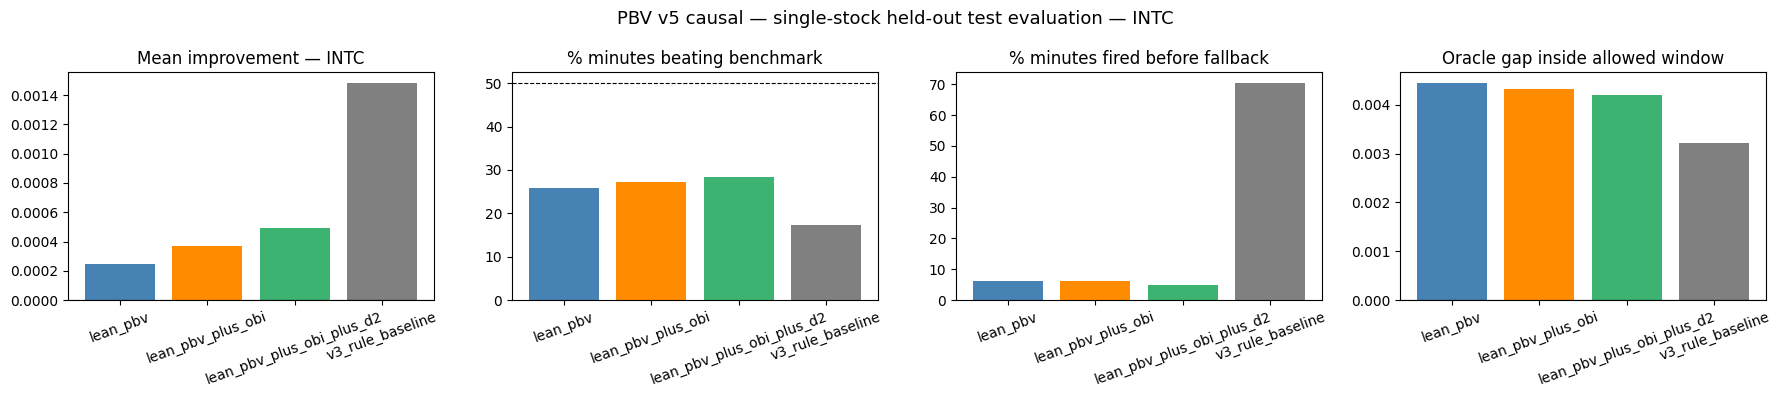


Validation-threshold search (single stock):

lean_pbv
 threshold  mean_improvement  beat_pct  fire_pct   exec_s  oracle_gap
   0.50000           0.00211  31.57895  18.42105 42.26613     0.00553
   0.52500           0.00211  31.57895  15.78947 42.98271     0.00553
   0.55000           0.00211  31.57895  15.78947 43.04329     0.00553
   0.57500           0.00211  31.57895  15.78947 43.04505     0.00553
   0.60000           0.00237  34.21053  15.78947 43.13813     0.00526
   0.62500           0.00237  34.21053  15.78947 43.34389     0.00526
   0.65000           0.00211  34.21053  10.52632 43.49111     0.00553
   0.67500           0.00237  34.21053  10.52632 43.53053     0.00526
   0.70000           0.00237  34.21053   7.89474 43.73524     0.00526
   0.72500           0.00211  31.57895   7.89474 43.73989     0.00553
   0.75000           0.00211  31.57895   7.89474 43.79121     0.00553
   0.77500           0.00158  28.94737   7.89474 43.86305     0.00605
   0.80000           0.00158  28.94

In [18]:
# ============================================================
# CELL 7: Single-Stock Test Evaluation — Threshold Tuned on Validation Only
# ============================================================
single_stock_rows = []
res_map = {}
threshold_map = {}
val_tuning_map = {}

for name, feats in model_specs.items():
    info = fit_results[name]
    best_thr, tune_df = tune_threshold(
        info['model'], info['scaler'], feats, info['df_val'], train_raw,
        benchmark_col='causal_ref', improvement_col='causal_improvement'
    )
    res = simulate_threshold(
        info['model'], info['scaler'], feats, info['df_test'], train_raw, best_thr,
        benchmark_col='eval_ref', improvement_col='eval_improvement'
    )

    threshold_map[name] = best_thr
    val_tuning_map[name] = tune_df
    res_map[name] = res
    single_stock_rows.append(
        summarize_results(name, res, val_auc=info['val_auc'], test_auc=info['test_auc'], prob_threshold=best_thr)
    )

res_v3 = simulate_v3_baseline(train_raw, test_mins, benchmark_col='eval_ref', improvement_col='eval_improvement')
res_map['v3_rule_baseline'] = res_v3
single_stock_rows.append(summarize_results('v3_rule_baseline', res_v3, val_auc=np.nan, test_auc=np.nan, prob_threshold=np.nan))

single_stock_summary = pd.DataFrame(single_stock_rows)
print(single_stock_summary.to_string(index=False, float_format=lambda x: f"{x:0.5f}"))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
labels = single_stock_summary['Model']
colors = ['steelblue', 'darkorange', 'mediumseagreen', 'gray']

axes[0].bar(labels, single_stock_summary['Mean $'], color=colors)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title(f"Mean improvement — {STOCK}")
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(labels, single_stock_summary['Beat %'], color=colors)
axes[1].axhline(50, color='black', lw=0.8, ls='--')
axes[1].set_title('% minutes beating benchmark')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(labels, single_stock_summary['Fire %'], color=colors)
axes[2].set_title('% minutes fired before fallback')
axes[2].tick_params(axis='x', rotation=20)

axes[3].bar(labels, single_stock_summary['Oracle gap $'], color=colors)
axes[3].axhline(0, color='black', lw=0.8)
axes[3].set_title('Oracle gap inside allowed window')
axes[3].tick_params(axis='x', rotation=20)

plt.suptitle(f"PBV v5 causal — single-stock held-out test evaluation — {STOCK}", fontsize=13)
plt.tight_layout()
plt.show()

print("\nValidation-threshold search (single stock):")
for name, tune_df in val_tuning_map.items():
    print(f"\n{name}")
    print(tune_df.to_string(index=False, float_format=lambda x: f"{x:0.5f}"))


In [19]:
# ============================================================
# CELL 8: Cross-Stock Evaluation
# ============================================================
def run_stock(stock):
    d = load_and_compute(stock)
    fit_mins_s, val_mins_s, test_mins_s = split_minutes(d)
    fit_pool_s = d[d['eligible'] & d['Minute'].isin(fit_mins_s)].copy()
    cutoff_s = fit_pool_s['causal_improvement'].quantile(TOP_Q)

    out = {}
    for name, feats in model_specs.items():
        _, df_fit_raw, df_val_raw, df_test_raw = build_dataset(d, feats, fit_mins_s, val_mins_s, test_mins_s)
        df_fit, df_val, df_test = apply_causal_label(df_fit_raw, df_val_raw, df_test_raw, cutoff_s)
        model, scaler, fit_auc, val_auc, test_auc = fit_model(feats, df_fit, df_val, df_test)
        best_thr, _ = tune_threshold(model, scaler, feats, df_val, d, benchmark_col='causal_ref', improvement_col='causal_improvement')
        res = simulate_threshold(model, scaler, feats, df_test, d, best_thr, benchmark_col='eval_ref', improvement_col='eval_improvement')
        out[name] = summarize_results(name, res, val_auc=val_auc, test_auc=test_auc, prob_threshold=best_thr)

    out['v3_rule_baseline'] = summarize_results(
        'v3_rule_baseline',
        simulate_v3_baseline(d, test_mins_s, benchmark_col='eval_ref', improvement_col='eval_improvement'),
        val_auc=np.nan,
        test_auc=np.nan,
        prob_threshold=np.nan,
    )
    return out


print('Running cross-stock PBV v5 causal pipeline...')
xs = {s: run_stock(s) for s in STOCKS_ALL}
print('Done.')

rows = []
for stock in STOCKS_ALL:
    for model_name in ['lean_pbv', 'lean_pbv_plus_obi', 'lean_pbv_plus_obi_plus_d2', 'v3_rule_baseline']:
        rows.append({
            'Stock': stock,
            'Model': model_name,
            **xs[stock][model_name],
        })

xs_df = pd.DataFrame(rows)
print(xs_df[['Stock','Model','Val AUC','Test AUC','Threshold','Mean $','Median $','Beat %','Fire %','Exec s','Oracle gap $']].to_string(index=False, float_format=lambda x: f"{x:0.5f}"))


Running cross-stock PBV v5 causal pipeline...
Done.
Stock                     Model  Val AUC  Test AUC  Threshold   Mean $  Median $   Beat %   Fire %   Exec s  Oracle gap $
 AMZN                  lean_pbv  0.62635   0.74989    0.72500  0.01074   0.02000 55.55556 38.27160 42.47740       0.06778
 AMZN         lean_pbv_plus_obi  0.78484   0.75766    0.62500  0.01358   0.02000 58.02469 82.71605 32.31162       0.06494
 AMZN lean_pbv_plus_obi_plus_d2  0.78479   0.75763    0.62500  0.01321   0.02000 58.02469 82.71605 32.34041       0.06531
 AMZN          v3_rule_baseline      NaN       NaN        NaN  0.01284   0.00000 45.67901 87.65432 15.95778       0.06568
 GOOG                  lean_pbv  0.92444   0.52516    0.90000 -0.00259   0.02000 58.02469  2.46914 43.23369       0.12691
 GOOG         lean_pbv_plus_obi  0.91853   0.37396    0.90000 -0.00259   0.02000 58.02469  2.46914 43.23369       0.12691
 GOOG lean_pbv_plus_obi_plus_d2  0.91118   0.37776    0.90000 -0.00259   0.02000 58.02469  2.4

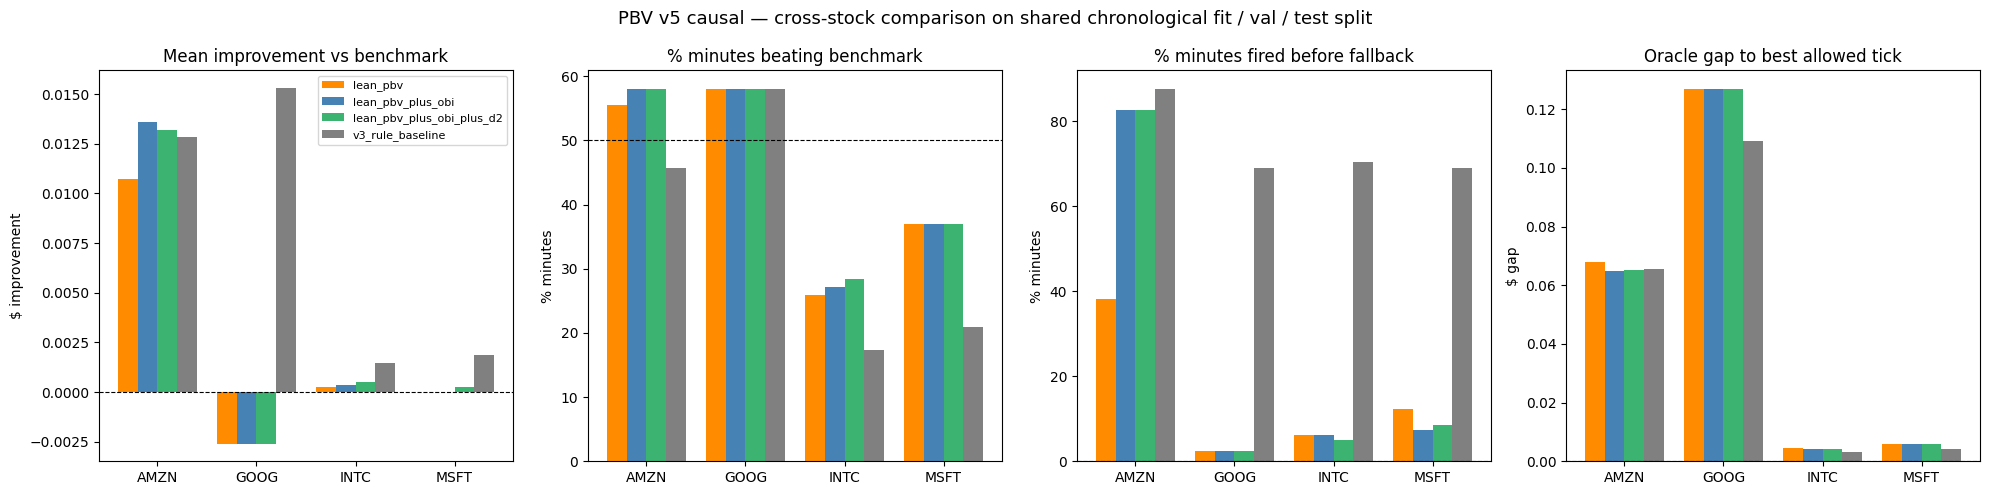

In [20]:
# ============================================================
# CELL 9: Cross-Stock Visual Summary
# ============================================================
plot_models = ['lean_pbv', 'lean_pbv_plus_obi', 'lean_pbv_plus_obi_plus_d2', 'v3_rule_baseline']
plot_colors = {
    'lean_pbv': 'darkorange',
    'lean_pbv_plus_obi': 'steelblue',
    'lean_pbv_plus_obi_plus_d2': 'mediumseagreen',
    'v3_rule_baseline': 'gray',
}

x = np.arange(len(STOCKS_ALL))
width = 0.2
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for j, (metric, ylabel, title) in enumerate([
    ('Mean $', '$ improvement', 'Mean improvement vs benchmark'),
    ('Beat %', '% minutes', '% minutes beating benchmark'),
    ('Fire %', '% minutes', '% minutes fired before fallback'),
    ('Oracle gap $', '$ gap', 'Oracle gap to best allowed tick'),
]):
    ax = axes[j]
    for i, model_name in enumerate(plot_models):
        vals = [xs[s][model_name][metric] for s in STOCKS_ALL]
        ax.bar(x + (i - 1.5) * width, vals, width, label=model_name, color=plot_colors[model_name])
    if metric == 'Beat %':
        ax.axhline(50, color='black', lw=0.8, ls='--')
    else:
        ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels(STOCKS_ALL)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[0].legend(fontsize=8)
plt.suptitle('PBV v5 causal — cross-stock comparison on shared chronological fit / val / test split', fontsize=13)
plt.tight_layout()
plt.show()


## Notes

- This notebook is a causal alternative to `pbv_v5_final`.
- The label is based on **current realized improvement** relative to a fit-set quantile, not the future best tick in the minute.
- Minutes are split chronologically into **fit / validation / test** blocks.
- The model is selected on **validation AUC only**; test AUC is reported only after selection.
- The execution rule is **sequential**: fire on the first eligible tick whose predicted probability clears a threshold tuned on validation minutes only.
- The `v3` baseline remains causal and serves as the hand-crafted comparator.
- The deep-OBI feature is still restricted to levels 2-5 to reduce redundancy with top-of-book PBV state.
